In [1]:
# PYTHON DA ASSIGNMENT 2
# DATA VISUALIZATION

# 1. IMPORT LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. LOADING THE TAXIS DATASET

df = sns.load_dataset("taxis")

print("First 5 Rows:")
print(df.head())

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


First 5 Rows:
               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Si

In [3]:
# 3. HANDLING MISSING VALUES

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [4]:
# Display only columns having missing values
missing_values = df.isnull().sum()

print("\nColumns with Missing Values:")
print(missing_values[missing_values > 0])



Columns with Missing Values:
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [5]:
# Check data types
print("\nData Types:")
print(df.dtypes)


Data Types:
pickup             datetime64[ns]
dropoff            datetime64[ns]
passengers                  int64
distance                  float64
fare                      float64
tip                       float64
tolls                     float64
total                     float64
color                      object
payment                    object
pickup_zone                object
dropoff_zone               object
pickup_borough             object
dropoff_borough            object
dtype: object


In [6]:
# Handle numerical missing values using median
numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())


In [7]:
# Handle categorical missing values using mode
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(df[column].mode()[0])

In [8]:
# Critical columns required for visualization
critical_columns = [
    'pickup',
    'fare',
    'distance',
    'payment',
    'pickup_borough',
    'pickup_zone'
]

df = df.dropna(subset=critical_columns)

In [9]:
# Check missing values after handling
print("\nMissing Values After Handling:")
print(df.isnull().sum())



Missing Values After Handling:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


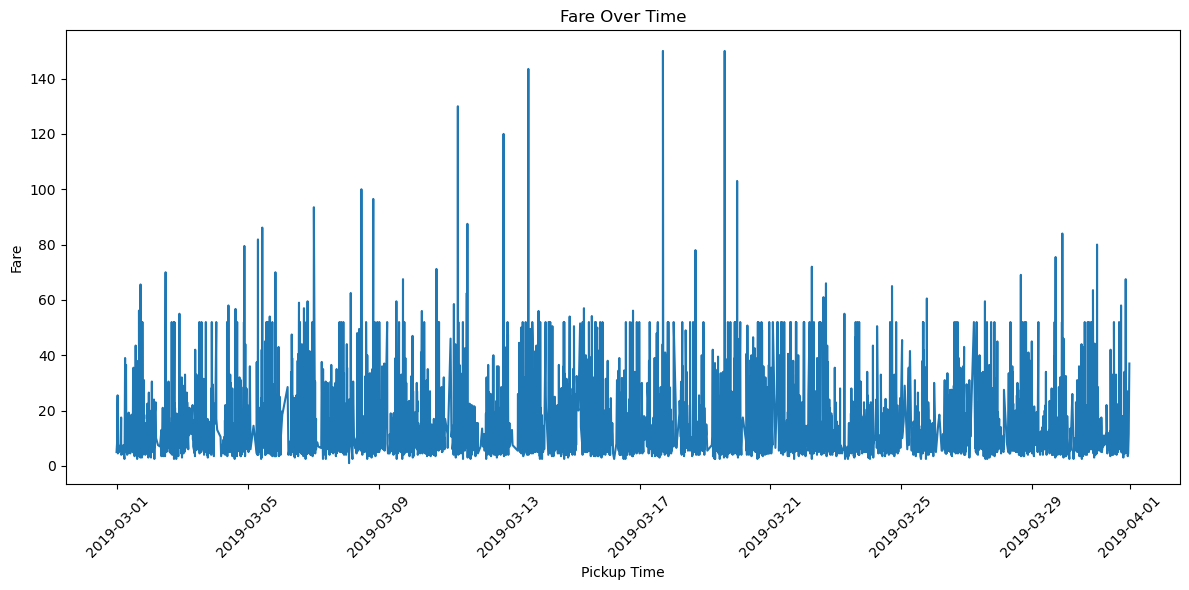

In [10]:
# 4. LINE CHART
# Fare Over Time

df['pickup'] = pd.to_datetime(df['pickup'])

df = df.sort_values('pickup')

plt.figure(figsize=(12, 6))

plt.plot(
    df['pickup'],
    df['fare']
)

plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Fare Over Time')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


Total Fare by Pickup Borough:
pickup_borough
Bronx         2078.91
Brooklyn      6327.48
Manhattan    59426.42
Queens       16382.06
Name: fare, dtype: float64


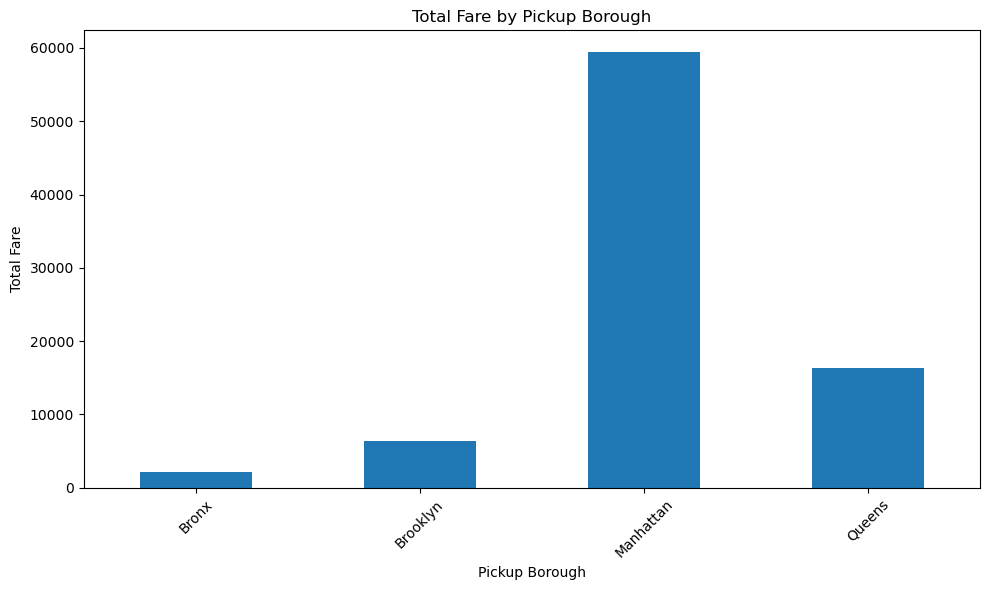

In [11]:
# 5. BAR CHART
# Total Fare by Pickup Borough

borough_fare = df.groupby(
    'pickup_borough'
)['fare'].sum()

print("\nTotal Fare by Pickup Borough:")
print(borough_fare)

plt.figure(figsize=(10, 6))

borough_fare.plot(kind='bar')

plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


Trips by Payment Method:
payment
credit card    4621
cash           1812
Name: count, dtype: int64


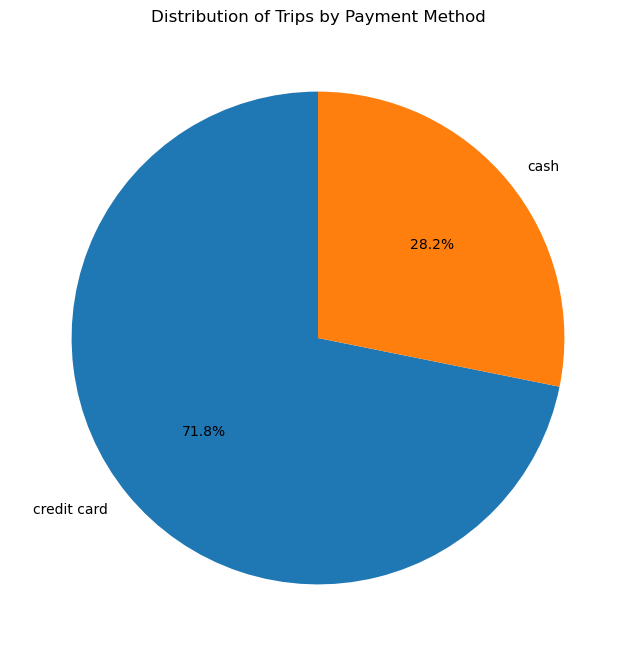

In [12]:
# 6. PIE CHART
# Distribution of Trips by Payment Method

payment_counts = df['payment'].value_counts()

print("\nTrips by Payment Method:")
print(payment_counts)

plt.figure(figsize=(8, 8))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Trips by Payment Method')

plt.show()

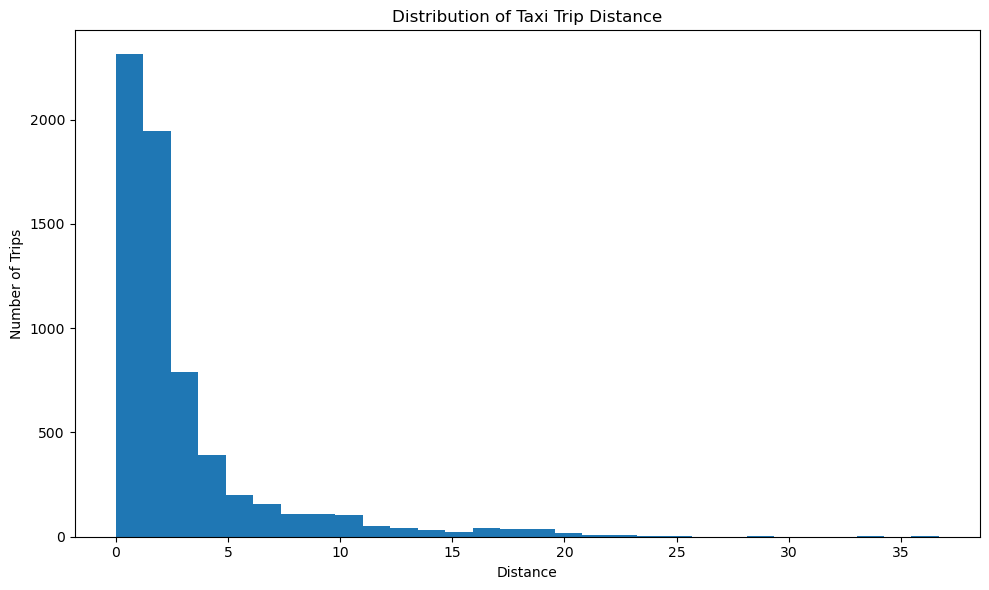

In [13]:
# 7. HISTOGRAM
# Distribution of Distance

plt.figure(figsize=(10, 6))

plt.hist(
    df['distance'],
    bins=30
)

plt.xlabel('Distance')
plt.ylabel('Number of Trips')
plt.title('Distribution of Taxi Trip Distance')

plt.tight_layout()

plt.show()

<Figure size 1000x600 with 0 Axes>

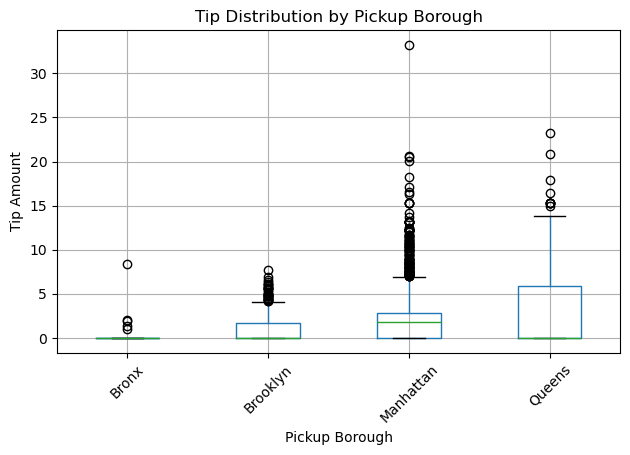

In [14]:
# 8. BOX PLOT
# Tip Distribution by Pickup Borough

plt.figure(figsize=(10, 6))

df.boxplot(
    column='tip',
    by='pickup_borough'
)

plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.title('Tip Distribution by Pickup Borough')

plt.suptitle('')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

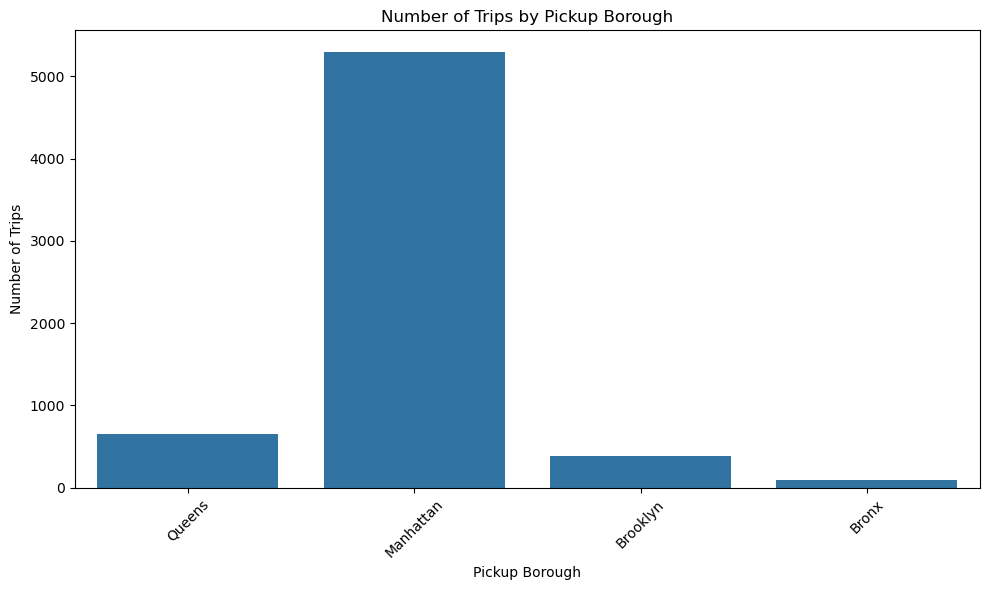

In [15]:
# 9. COUNT PLOT
# Number of Trips by Pickup Borough

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='pickup_borough'
)

plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.title('Number of Trips by Pickup Borough')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

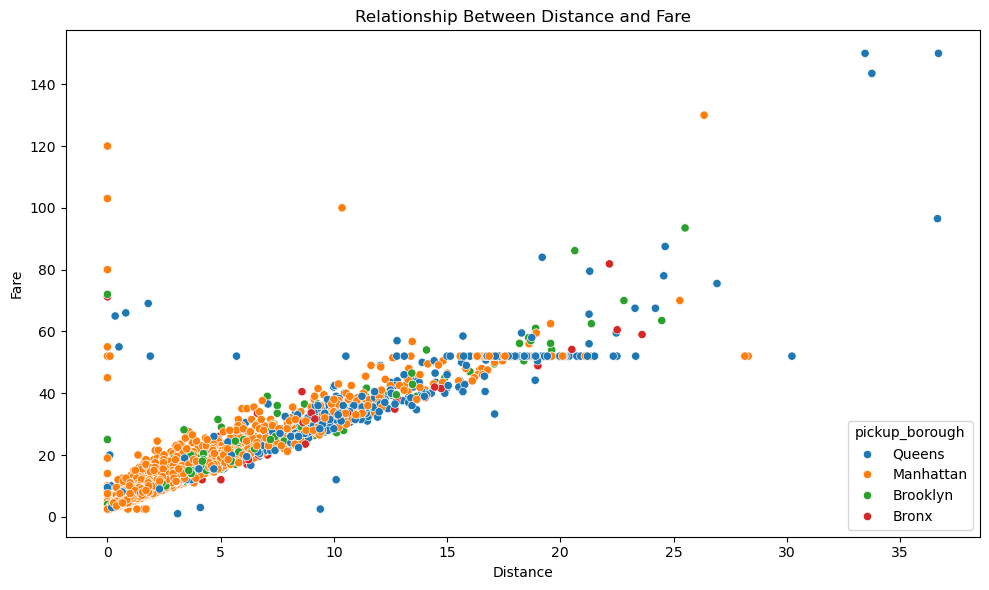

In [16]:
# 10. SCATTER PLOT
# Distance vs Fare

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='distance',
    y='fare',
    hue='pickup_borough'
)

plt.xlabel('Distance')
plt.ylabel('Fare')
plt.title('Relationship Between Distance and Fare')

plt.tight_layout()

plt.show()


Correlation Matrix:
          distance      fare       tip     tolls     total
distance  1.000000  0.920108  0.452589  0.635267  0.904676
fare      0.920108  1.000000  0.488612  0.609307  0.974358
tip       0.452589  0.488612  1.000000  0.413619  0.646186
tolls     0.635267  0.609307  0.413619  1.000000  0.683142
total     0.904676  0.974358  0.646186  0.683142  1.000000


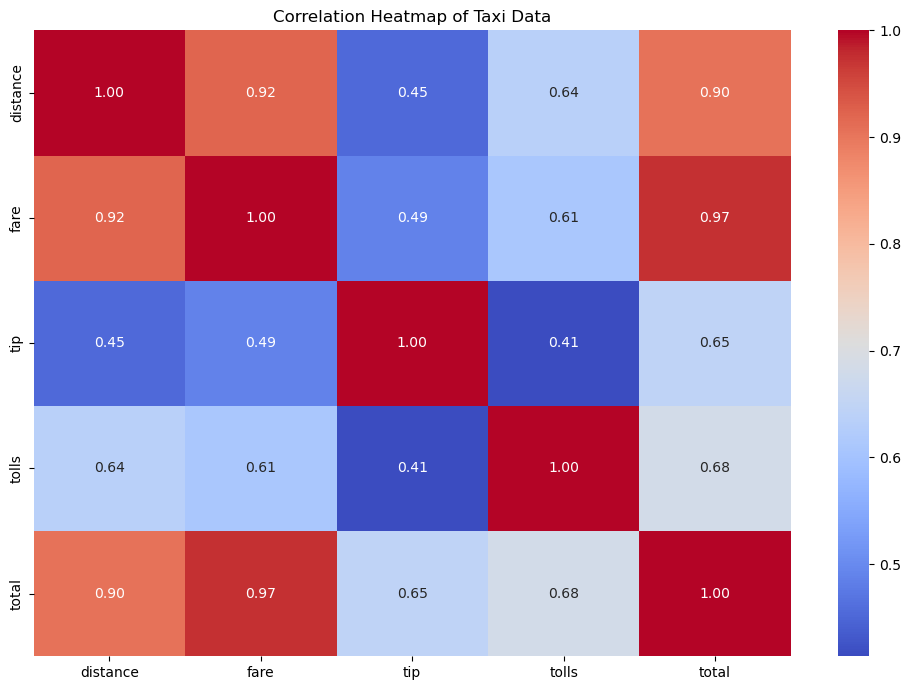

In [17]:
# 11. HEATMAP
# Correlation Matrix

numeric_data = df[
    ['distance', 'fare', 'tip', 'tolls', 'total']
]

correlation_matrix = numeric_data.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Taxi Data')

plt.tight_layout()

plt.show()

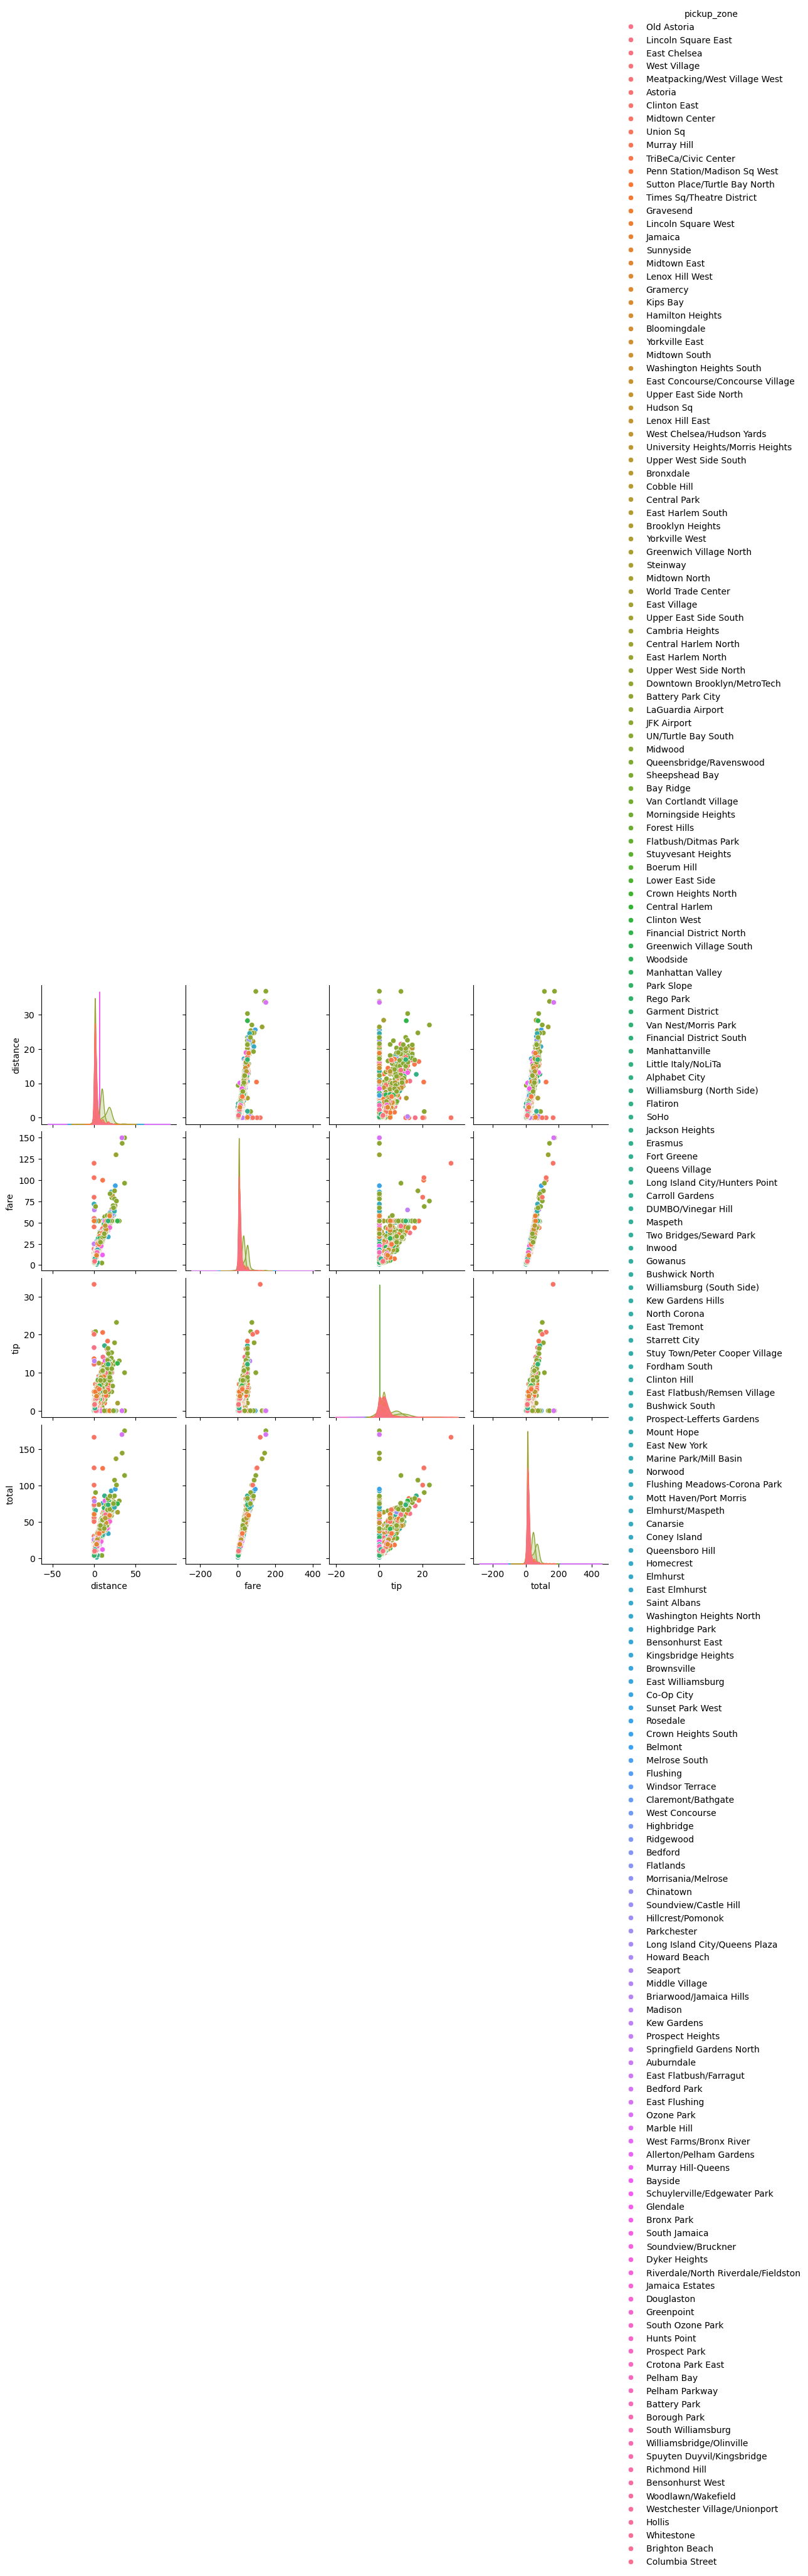

In [20]:
# 12. PAIR PLOT
# Pairwise Relationships

pair_data = df[
    ['distance', 'fare', 'tip', 'total', 'pickup_zone']
].dropna()

sns.pairplot(
    pair_data,
    vars=[
        'distance',
        'fare',
        'tip',
        'total'
    ],
    hue='pickup_zone'
)

plt.show()

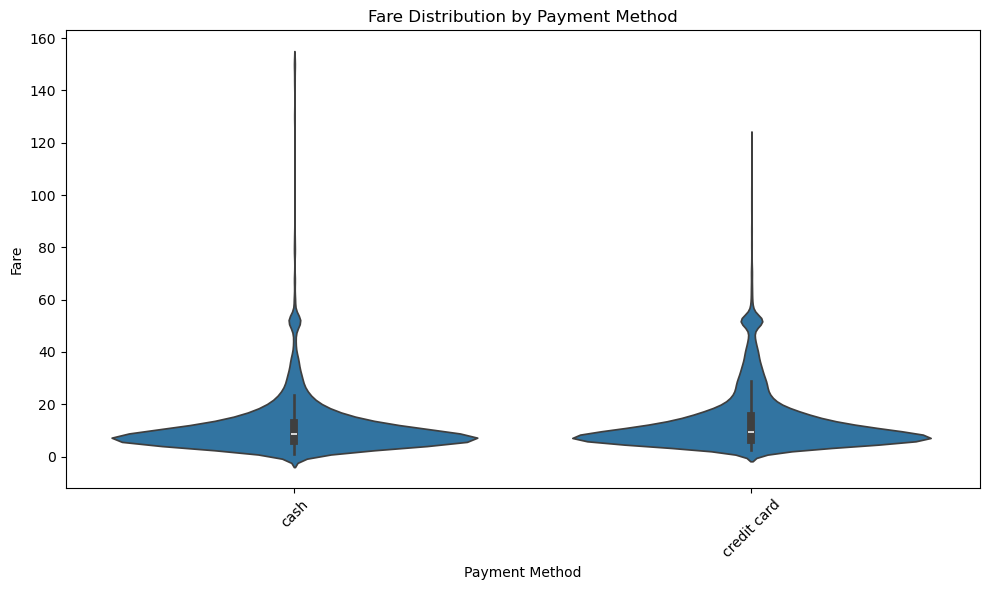

In [21]:
# 13. VIOLIN PLOT
# Fare Distribution by Payment Method
# ============================================

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='payment',
    y='fare'
)

plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.title('Fare Distribution by Payment Method')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()